# R Nearest Neighbors Classification
> documentation: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.RadiusNeighborsClassifier.html

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets

In [2]:
iris = datasets.load_iris()

In [3]:
df = pd.DataFrame({'Sepal length': iris.data[:,0],
                   'Sepal width': iris.data[:,1],
                   'Petal length':iris.data[:,2],
                   'Petal width':iris.data[:,3],
                   'Species':iris.target})
df.head()

,Sepal length,Sepal width,Petal length,Petal width,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
df = df[df['Species'] != 0]

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 50 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal length  100 non-null    float64
 1   Sepal width   100 non-null    float64
 2   Petal length  100 non-null    float64
 3   Petal width   100 non-null    float64
 4   Species       100 non-null    int32  
dtypes: float64(4), int32(1)
memory usage: 4.3 KB


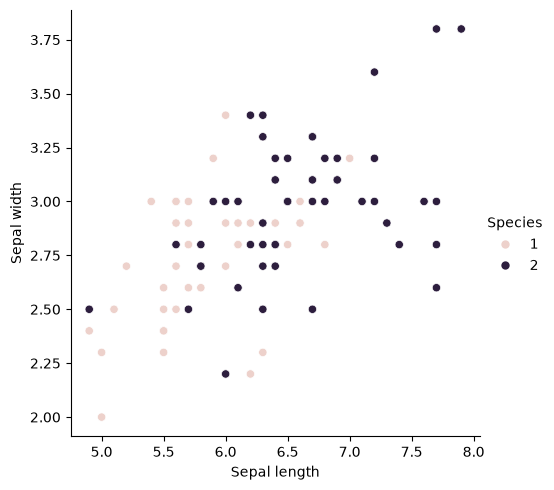

In [6]:
sns.relplot(data = df, x = 'Sepal length', y = 'Sepal width', hue = 'Species')

In [7]:
from sklearn.model_selection import train_test_split

X = df[df.columns[:2]]
y = df[df.columns[-1]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

In [8]:
X_train[:5]

,Sepal length,Sepal width
116,6.5,3.0
51,6.4,3.2
121,5.6,2.8
91,6.1,3.0
141,6.9,3.1


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
X_train[:5]

array([[ 0.30188605,  0.33619872],
       [ 0.1563988 ,  0.94060092],
       [-1.00749923, -0.26820348],
       [-0.28006296,  0.33619872],
       [ 0.88383507,  0.63839982]])

## R-Nearest Neighbors

In [11]:
r = 1

In [12]:
from sklearn.neighbors import RadiusNeighborsClassifier

classifier = RadiusNeighborsClassifier(radius = r)
classifier.fit(X_train, y_train)

,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.This parameter is expected to be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"outlier_label outlier_label: {manual label, 'most_frequent'}, default=NoneLabel for outlier samples (samples with no neighbors in given radius).- manual label: str or int label (should be the same type as y) or list of manual labels if multi-output is used.- 'most_frequent' : assign the most frequent label of y to outliers.- None : when any outlier is detected, ValueError will be raised.The outlier label should be selected from among the unique 'Y' labels.If it is specified with a different value a warning will be raised andall class probabilities of outliers will be assigned to be 0.",None
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier.","ndarray[int32](2,)","[1,2]"


In [13]:
y_pred = classifier.predict(X_test)

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

result = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(result)
result1 = classification_report(y_test, y_pred)
print("Classification Report:",)
print (result1)
result2 = accuracy_score(y_test,y_pred)
print("Accuracy:",result2)

Confusion Matrix:
[[8 3]
 [5 4]]
Classification Report:
              precision    recall  f1-score   support

           1       0.62      0.73      0.67        11
           2       0.57      0.44      0.50         9

    accuracy                           0.60        20
   macro avg       0.59      0.59      0.58        20
weighted avg       0.60      0.60      0.59        20

Accuracy: 0.6


## Best r

In [15]:
def rnn_tuning(r):
  classifier = RadiusNeighborsClassifier(radius = r)
  classifier.fit(X_train, y_train)
  y_pred = classifier.predict(X_test)
  accuracy = accuracy_score(y_test,y_pred)
  return accuracy

In [16]:
rnn_tuning(1)

0.6

In [17]:
rnn_tuning(5)

0.6

In [18]:
rnn_results = pd.DataFrame({'R':np.arange(1, 10, 0.5)})

In [19]:
rnn_results['R']

0     1.0
1     1.5
2     2.0
3     2.5
4     3.0
5     3.5
6     4.0
7     4.5
8     5.0
9     5.5
10    6.0
11    6.5
12    7.0
13    7.5
14    8.0
15    8.5
16    9.0
17    9.5
Name: R, dtype: float64

In [20]:
rnn_results['Accuracy'] = rnn_results['R'].apply(rnn_tuning)
rnn_results['Accuracy']

0     0.60
1     0.60
2     0.65
3     0.65
4     0.70
5     0.65
6     0.70
7     0.60
8     0.60
9     0.45
10    0.45
11    0.45
12    0.45
13    0.45
14    0.45
15    0.45
16    0.45
17    0.45
Name: Accuracy, dtype: float64

In [21]:
rnn_results

,R,Accuracy
0,1.0,0.60
1,1.5,0.60
2,2.0,0.65
3,2.5,0.65
4,3.0,0.70
5,3.5,0.65
6,4.0,0.70
7,4.5,0.60
8,5.0,0.60
9,5.5,0.45


## Optimize weights

In [22]:
def rnn_tuning_uniform(r):
  classifier = RadiusNeighborsClassifier(radius = r, weights= 'uniform')
  classifier.fit(X_train, y_train)
  y_pred = classifier.predict(X_test)
  accuracy = accuracy_score(y_test,y_pred)
  return accuracy

In [23]:
def rnn_tuning_distance(k):
  classifier = RadiusNeighborsClassifier(radius = k, weights= 'distance')
  classifier.fit(X_train, y_train)
  y_pred = classifier.predict(X_test)
  accuracy = accuracy_score(y_test,y_pred)
  return accuracy

In [24]:
rnn_results['Uniform'] = rnn_results['R'].apply(rnn_tuning_uniform)
rnn_results['Distance'] = rnn_results['R'].apply(rnn_tuning_distance)
rnn_results

,R,Accuracy,Uniform,Distance
0,1.0,0.60,0.60,0.65
1,1.5,0.60,0.60,0.70
2,2.0,0.65,0.65,0.70
3,2.5,0.65,0.65,0.70
4,3.0,0.70,0.70,0.70
5,3.5,0.65,0.65,0.70
6,4.0,0.70,0.70,0.70
7,4.5,0.60,0.60,0.70
8,5.0,0.60,0.60,0.70
9,5.5,0.45,0.45,0.70
